# K-Nearest Neighbors

En este script de Python veremos como implementar en código todo lo que vimos ya conceptualmente. Python tiene muchas funciones que nos facilitan la vida, y por eso es importante saber qué es lo que está haciendo la computadora cuando hacemos código, y no sólo escribir código a lo tonto.

### Paso 1: Importamos las principales bibliotecas que vamos a utilizar en la sesión.
Abrá otras que importareamos después según vayamos requiriendo las funciones

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Paso 2: descargo e importo la base de datos

In [ ]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/d546eaee765268bf2f487608c537c05e22e4b221/iris.csv'

In [ ]:
iris = pd.read_csv(url)
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Imaginémonos que nuestro KNN va a clasificar con base en dos atributos nada más. ¿Qué vemos en la gráfica? Los azules todo bien pero, ¿es clara la "diferencia" entre naranjas y verdes? ¿Cómo lo podríamos solucionar?


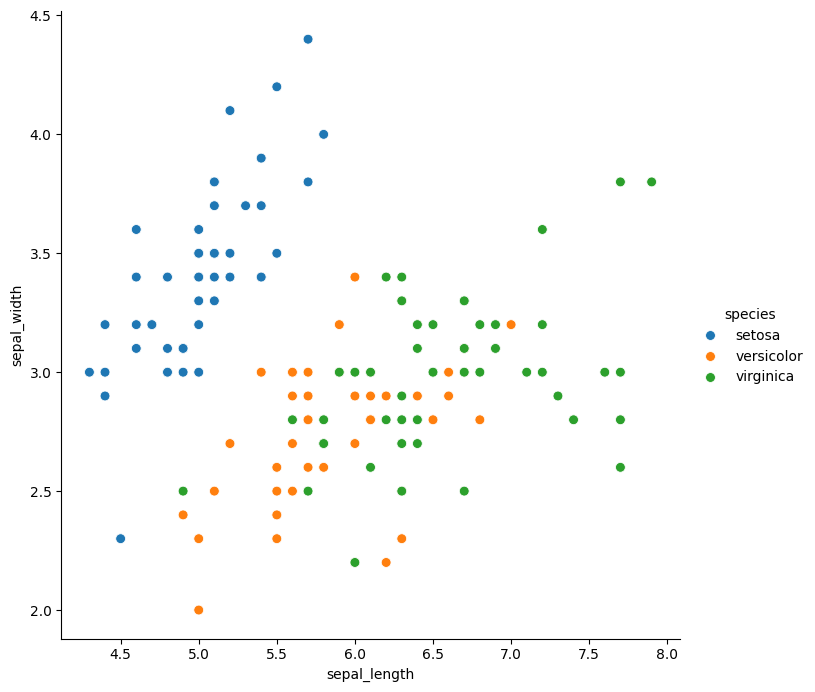

In [ ]:
sns.pairplot(x_vars='sepal_length', y_vars='sepal_width', data=iris, plot_kws={'s': 50}, height=7, hue='species')

### Paso 3: Separo mi base en atributos (variables independientes, si quieren verlo así) y etiquetas (variable dependiente)

In [ ]:
# Set de características
x = iris.iloc[:, :4].values # 0, 1, 2, 3
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
# Columna de respuestas
y = iris.iloc[:, 4].values
y

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

#¿Knearest ?

![knearest](https://miro.medium.com/max/1022/1*AuXDgGrr0wbCoF6KDXXSZQ.jpeg)


El algoritmo k-nearest neighbors (KNN) es un algoritmo de aprendizaje automático simple y supervisado que puede utilizarse para resolver tanto problemas de clasificación como de regresión. Es fácil de implementar y entender, pero tiene el gran inconveniente de volverse significativamente lento a medida que crece el tamaño de los datos en uso.
KNN funciona encontrando las distancias entre una consulta y todos los ejemplos de los datos, seleccionando el número especificado de ejemplos (K) más cercanos a la consulta, y luego vota por la etiqueta más frecuente (en el caso de la clasificación) o promedia las etiquetas (en el caso de la regresión).
En el caso de la clasificación y la regresión, la elección de la K correcta para nuestros datos se realiza probando varias K y eligiendo la que mejor funciona.


En la clasificación k-NN, el resultado es la pertenencia a una clase. Un objeto se clasifica mediante un voto plural de sus vecinos, asignando el objeto a la clase más común entre sus k vecinos más cercanos (k es un número entero positivo, normalmente pequeño). Si k = 1, el objeto se asigna simplemente a la clase de ese único vecino más cercano.

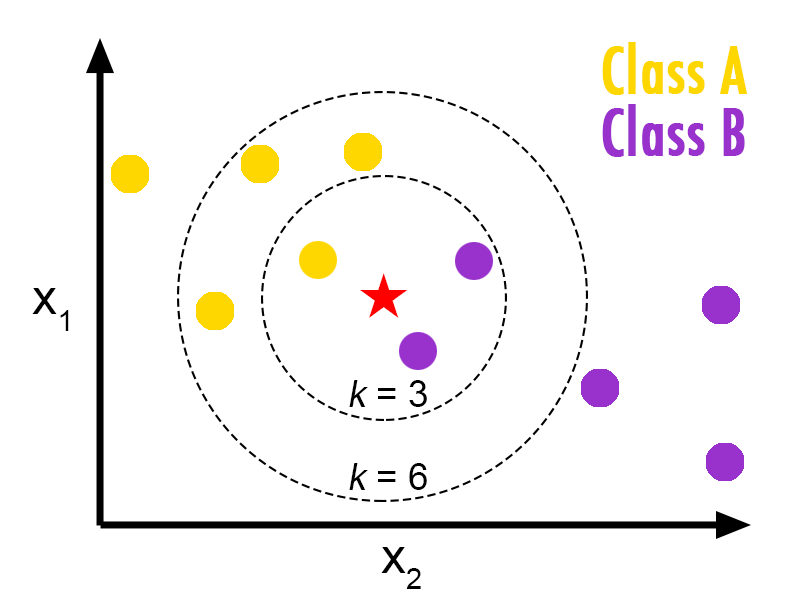

![tomato](https://jiayiwangjw.github.io/img/KNN/tomato.png)

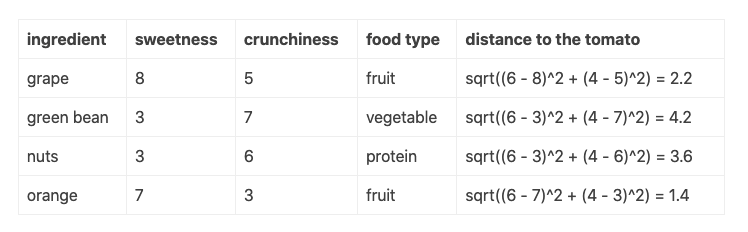

### Paso 4: Vamos a dividir nuestra base en una base de entrenamiento y otra de prueba. Dejemos 80% para que el KNN memorice, y 20% para ver qué tan bien "aprendió" a clasificar

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [ ]:
# Conjunto de entrenamiento
len(x_train)

120

In [ ]:
# Conjunto de pruebas
len(x_test)

30

En teoría, una buena K para empezar a explorar es la raíz cuadrada del número de observaciones de mi base de entrenamiento. En este caso es la raíz de 120, es decir, 11 aproximadamente.

In [ ]:
import math
math.sqrt(len(x_train))

10.954451150103322

![good_k](https://jiayiwangjw.github.io/img/KNN/how%20much%20is%20K.png)

### Paso 5: Normalizo mis datos para que tengan una escala común

Primero importo la función que me permite normalizar facilmente, y luego le digo que calcule media y desviación que va a usar luego para normalizar (en la parte del fit).

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(x_train) # Construimos las equivalencias
# 7.3 -> 1, 5.0 -> 0, 6.1 -> 0.5

MinMaxScaler()

Ahora sí, re-escalo mis variables

In [ ]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_test

array([[ 0.22857143,  0.78947368,  0.08474576,  0.04166667],
       [ 0.51428571,  0.47368421,  0.55932203,  0.5       ],
       [ 0.57142857,  0.63157895,  0.59322034,  0.58333333],
       [ 0.22857143,  1.10526316,  0.08474576,  0.        ],
       [ 0.31428571,  0.26315789,  0.50847458,  0.5       ],
       [ 0.37142857,  0.42105263,  0.52542373,  0.5       ],
       [ 0.4       ,  0.36842105,  0.49152542,  0.45833333],
       [ 0.57142857,  0.42105263,  0.77966102,  0.875     ],
       [ 0.6       ,  0.52631579,  0.76271186,  0.70833333],
       [ 0.51428571,  0.42105263,  0.6440678 ,  0.70833333],
       [ 0.31428571,  0.78947368,  0.05084746,  0.04166667],
       [ 0.34285714,  0.52631579,  0.59322034,  0.58333333],
       [ 0.31428571,  1.15789474,  0.06779661,  0.04166667],
       [ 0.2       ,  0.78947368,  0.06779661,  0.04166667],
       [ 0.54285714,  0.68421053,  0.84745763,  1.        ],
       [ 0.45714286,  0.73684211,  0.59322034,  0.625     ],
       [ 0.8       ,  0.

In [ ]:
x_train.min(), x_train.max()

(0.0, 1.0)

### Paso 6: Importo mi clasificador y le digo que memorice los datos de entrenamiento

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=11)
classifier.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=11)

### Paso 7: Hago la predicción con mis atributos del set de prueba

In [ ]:
y_pred = classifier.predict(x_test)
y_pred

array(['setosa', 'versicolor', 'versicolor', 'setosa', 'versicolor',
       'versicolor', 'versicolor', 'virginica', 'virginica', 'virginica',
       'setosa', 'versicolor', 'setosa', 'setosa', 'virginica',
       'versicolor', 'virginica', 'virginica', 'setosa', 'virginica',
       'versicolor', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa'], dtype=object)

### Paso 8: revisamos qué tan bien lo hicimos

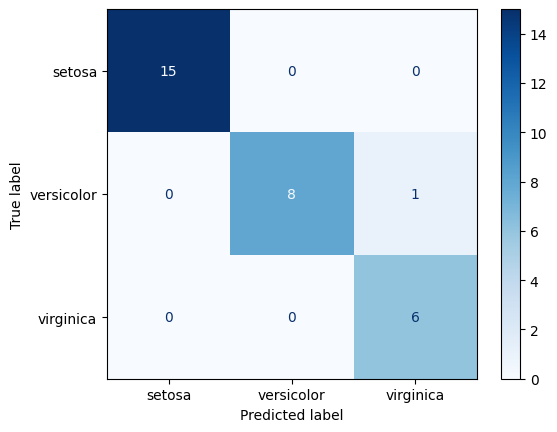

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
class_names = ['setosa', 'versicolor', 'virginica']
normalize = None
ConfusionMatrixDisplay.from_estimator(
        classifier,
        x_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.89      0.94         9
   virginica       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.96      0.95        30
weighted avg       0.97      0.97      0.97        30



**EXTRA: podemos ver con nuestro set de prueba el número de errores promedio que tendríamos con distintas K's

In [ ]:
error = []

for i in range(1, 50):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train, y_train)
    pred_i = knn.predict(x_test)
    error.append(np.mean(pred_i != y_test))

error

[0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.0,
 0.03333333333333333,
 0.0,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.0,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.03333333333333333,
 0.0,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.0,
 0.03333333333333333,
 0.03333333333333333,
 0.03333333333333333,
 0.06666666666666667,
 0.03333333333333333,
 0.03333333333333333,
 0.0,
 0.03333333333333333,
 0.06666666666666667,
 0.06666666666666667,
 0.13333333333333333]

(0.0, 0.2)

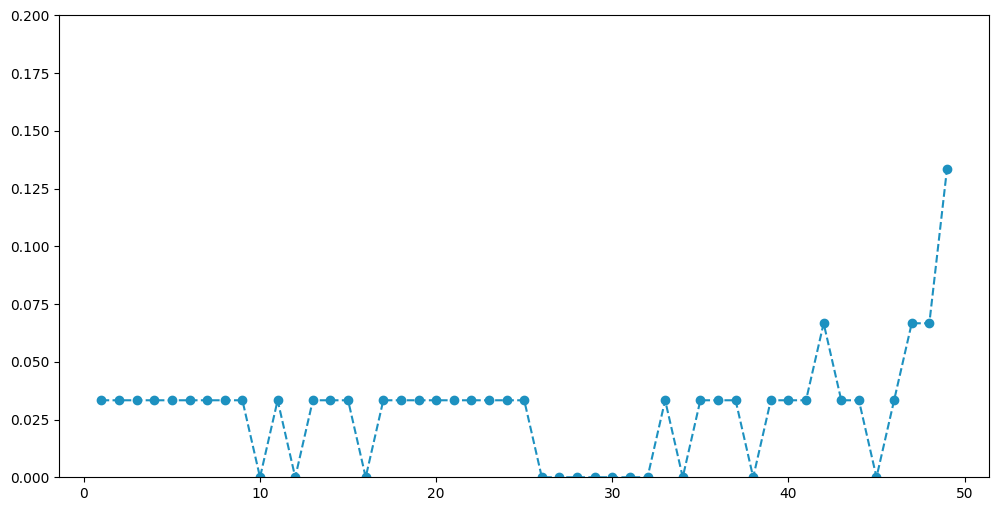

In [ ]:
plt.figure(figsize = (12, 6))
plt.plot(range(1, 50), error, color = '#1d91c0', linestyle = 'dashed', marker = 'o')
plt.ylim(0, 0.2)